## Neural Network Solver: Hodgkin–Huxley ODE System

Solves the Hodgkin–Huxley system of four coupled ODEs:

$$C_m \frac{dV}{dt} = I_\text{ext} - g_\text{Na} m^3 h (V - E_\text{Na})
  - g_K n^4 (V - E_K) - g_L (V - E_L)$$

$$\frac{dm}{dt} = \alpha_m(V)(1-m) - \beta_m(V) m$$

$$\frac{dh}{dt} = \alpha_h(V)(1-h) - \beta_h(V) h$$

$$\frac{dn}{dt} = \alpha_n(V)(1-n) - \beta_n(V) n$$

Domain: $t \in [0, 30]$ ms — shortened to contain two oscillatory cycles
($t \approx 2$ ms and $t \approx 17$ ms), following the short-observation-window
regime used in Wei et al. (2026). Initial conditions at resting state
$V_0 = -65$ mV.

This solves the **inverse-observability problem**: only voltage $V$ is ever
observed; the gating variables $m$, $h$, $n$ receive no direct data supervision
at any point after $t=0$ and must be reconstructed purely from the physics
residual. Training proceeds through four sequential phases, each building on
the params from the previous one:

| Phase | `data_mask` | `residual_weight` | `loss_weights` (V, m, h, n) | Steps | Purpose |
|---|---|---|---|---|---|
| 0 — Data generation | — | — | — | — | Radau reference (dense grid) + N=70 sparse noisy V-only data, spike-biased toward both oscillation windows |
| Pre-training | `[T,F,F,F]` | 0.0 | — | 10k | Fit V to data with physics off; gates receive no signal beyond the $t=0$ IC |
| Phase A | `[T,F,F,F]` | 1.0 | `(0.0, 0.2, 0.2, 0.2)` | 14k | Switch physics on for the gates only — V's own physics term stays zeroed so its data fit is undisturbed, while $m,h,n$ are pulled into ODE-consistency with the now-accurate V |
| Phase B | `[T,F,F,F]` | 1.0 | `(0.02, 0.2, 0.2, 0.2)` | 14k | Joint fine-tune — a small physics weight is reintroduced for V on top of its continuous data supervision, lightly regularising it now that the gates are already consistent |

In [ ]:
import sys; sys.path.insert(0, "..")
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from hh_pinn.model import init_params
from hh_pinn.trainer import Trainer
from hh_pinn.hh import HHProblem, _u

#### Phase 0: Data Generation

Dense Radau reference (1000 points, `[0, 30]` ms) as ground truth, then a
sparse noisy subset (N=70, uniform random, `σ_V = 2 mV`, `σ_gate = 0.01`) concentrated around spikes (biased sampling) standing in for real patch-clamp observations.

In [4]:
T_END = 30.0  # shortened domain, containing 2 oscillatory cycles (t≈2, t≈17 ms)

ref_problem = HHProblem(I_ext=10.0, t_end=T_END)
t_dense = np.linspace(0, T_END, 1000).astype(np.float32)
u_dense = ref_problem.true_solution(t_dense)

def biased_sample(n_spike_each, n_uniform, seed=42, sigma_V=2.0, sigma_gate=0.01):
    """15 points concentrated in each spike window, 40 uniform elsewhere --
    resolves the fast upstroke/downstroke that random uniform sampling
    under-covers (error was 63.5% near spikes vs 2.8% elsewhere before this fix)."""
    rng = np.random.default_rng(seed)
    t1 = rng.uniform(1.0, 4.0, n_spike_each)     # spike 1 window
    t2 = rng.uniform(15.0, 19.0, n_spike_each)   # spike 2 window
    t_rest = rng.uniform(0, T_END, n_uniform)
    idx1 = np.array([np.argmin(np.abs(t_dense - t)) for t in t1])
    idx2 = np.array([np.argmin(np.abs(t_dense - t)) for t in t2])
    idxr = np.array([np.argmin(np.abs(t_dense - t)) for t in t_rest])
    idx = np.unique(np.concatenate([idx1, idx2, idxr]))
    idx.sort()
    dt_ = t_dense[idx]
    du_ = u_dense[idx].copy()
    du_[:, 0]  += rng.normal(0, sigma_V, len(idx))
    du_[:, 1:] += rng.normal(0, sigma_gate, (len(idx), 3))
    return dt_, du_

data_t, data_u = biased_sample(n_spike_each=15, n_uniform=40, seed=42)
print(f"N (after dedup): {len(data_t)}")
print(f"Data V range: [{data_u[:,0].min():.1f}, {data_u[:,0].max():.1f}] mV")

N (after dedup): 68
Data V range: [-75.6, 38.0] mV


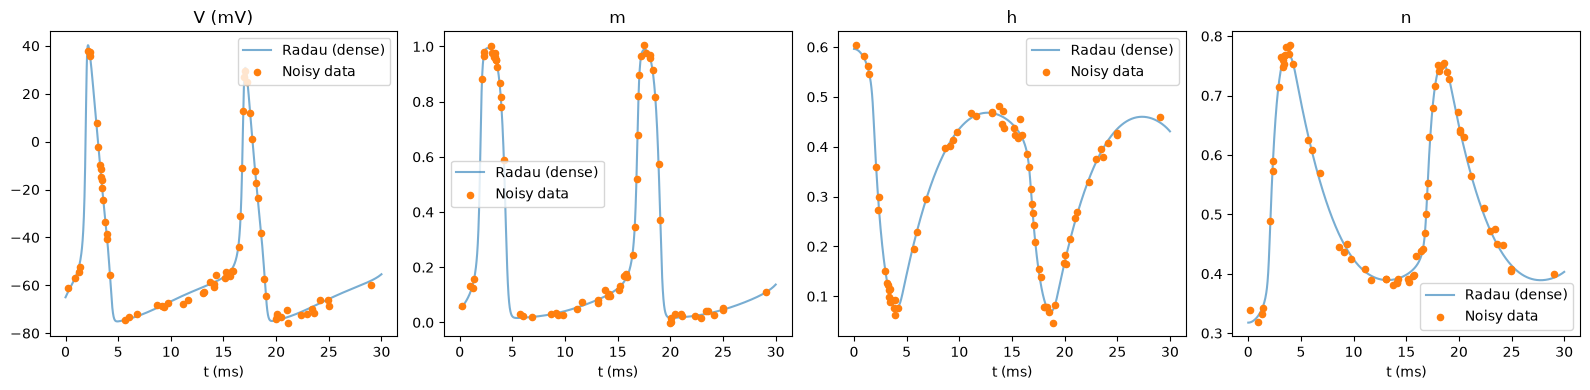

In [5]:
# Milestone 0: spike should be visible in the noisy data despite noise
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i, name in zip(axes, range(4), ["V (mV)", "m", "h", "n"]):
    ax.plot(t_dense, u_dense[:, i], label="Radau (dense)", alpha=0.6)
    ax.scatter(data_t, data_u[:, i], color="C1", s=20, zorder=5, label="Noisy data")
    ax.set_title(name); ax.set_xlabel("t (ms)"); ax.legend()
plt.tight_layout(); plt.show()

In [6]:
# -------------------- Helpers -------------------------
def make_problem(data_mask, dt=data_t, du=data_u):
    return HHProblem(I_ext=10.0, t_end=T_END, data_t=dt, data_u=du,
                     data_mask=data_mask, ic_weight=50.0)

t_eval = np.linspace(0, T_END, 300).astype(np.float32)
u_ref_eval = ref_problem.true_solution(t_eval)

def eval_trajectory(trainer, t_eval):
    return np.array([_u(trainer.params, trainer._apply, jnp.array(float(ti))).tolist()
                     for ti in t_eval])

def rel_l2_report(u_pred, u_ref, label):
    names = ["V", "m", "h", "n"]
    errs = [np.linalg.norm(u_pred[:, i] - u_ref[:, i]) / (np.linalg.norm(u_ref[:, i]) + 1e-8)
            for i in range(4)]
    print(f"{label}: " + "  ".join(f"{n}={e:.3f}" for n, e in zip(names, errs))
          + f"  avg={np.mean(errs):.3f}  max={np.max(errs):.3f}")
    return errs

def plot_vs_radau(t_eval, u_pred, u_ref, title, data_t=None, data_u=None, data_mask=None):
    """
    Compare PINN predictions against the Radau reference across all four
    state variables, with optional overlay of the actual training data points
    (only shown for variables where data_mask is True, matching Stage 2's
    partial-observation setup).
    """
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(title)
    names = ["V (mV)", "m", "h", "n"]
    for i, (ax, name) in enumerate(zip(axes, names)):
        ax.plot(t_eval, u_ref[:, i],  label="Radau", linewidth=1.5)
        ax.plot(t_eval, u_pred[:, i], "--", label="PINN", linewidth=1.5)
        if data_t is not None and data_mask is not None and data_mask[i]:
            ax.scatter(data_t, data_u[:, i], color="C2", s=15, zorder=5,
                      alpha=0.6, label="Data")
        ax.set_title(name)
        ax.set_xlabel("t (ms)")
        ax.legend(fontsize=8)
    plt.tight_layout()
    return fig

#### Pre-training (V-only, physics off)

In [13]:
data_mask_v_only = [True, False, False, False]

problem_pre2 = make_problem(data_mask_v_only)
params0_s2, activation = init_params(input_dim=1, hidden=(128, 128, 64), output_dim=4,
                                     activation='tanh', key=jax.random.PRNGKey(1))
trainer_pre2 = Trainer(params0_s2, activation, problem_pre2, lr=1e-3,
                       residual_weight=0.0, supervised_weight=1.0,
                       use_grad_clip=True, grad_clip_norm=0.1)
trainer_pre2.train(steps=10_000, batch_size=64, tol=1e-9, log_every=10_000)

step  10000 | mean loss: 0.0169 | 14.5s


[{'step': 10000,
  'mean_loss': 0.016938167027570308,
  'res_per_var': Array([9.1525104e+02, 7.3539619e+00, 6.3560508e-02, 2.4006523e-02],      dtype=float32)}]

Pre-train: V=0.058  m=1.501  h=1.274  n=0.588  avg=0.855  max=1.501
Spike visible (V_max > 10 mV): True


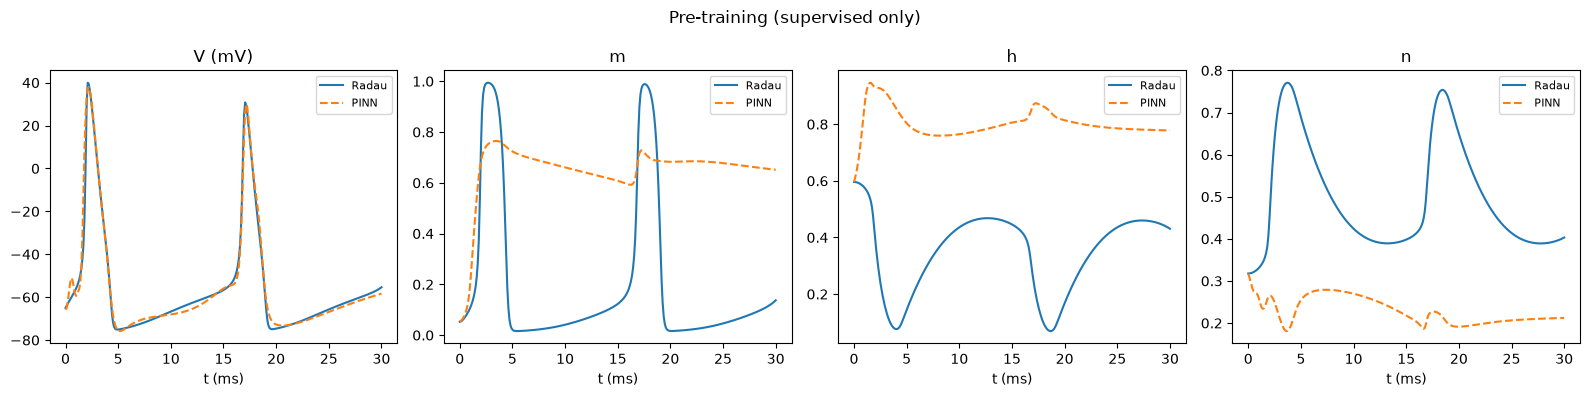

In [14]:
u_pre2 = eval_trajectory(trainer_pre2, t_eval)
plot_vs_radau(t_eval, u_pre2, u_ref_eval, "Pre-training (supervised only)")
rel_l2_report(u_pre2, u_ref_eval, "Pre-train")
print("Spike visible (V_max > 10 mV):", u_pre2[:, 0].max() > 10)

#### Phase A: gate-consistency physics (V excluded from physics via loss_weights)

In [15]:
GATE_W = 0.2   # revised down from 0.3 -- V's tighter data fit here needs less
               # compensating physics pressure on the gates

problem_a = make_problem(data_mask_v_only)
trainer_a = Trainer(trainer_pre2.params, activation, problem_a,
                    lr=5e-4, residual_weight=1.0,
                    loss_weights=[0.0, GATE_W, GATE_W, GATE_W],
                    use_grad_clip=True, grad_clip_norm=0.1)
trainer_a.train(steps=14_000, batch_size=64, tol=1e-9, log_every=14_000)

step  14000 | mean loss: 0.0155 | 20.4s


[{'step': 14000,
  'mean_loss': 0.015463979728087517,
  'res_per_var': Array([2.7749645e-02, 1.4978202e-04, 6.7038112e-05, 3.9067811e-05],      dtype=float32)}]

Phase A: V=0.038  m=0.053  h=0.030  n=0.012  avg=0.033  max=0.053


[np.float64(0.03755018701617718),
 np.float64(0.05284755157564528),
 np.float64(0.029725015483814333),
 np.float64(0.011745883379356808)]

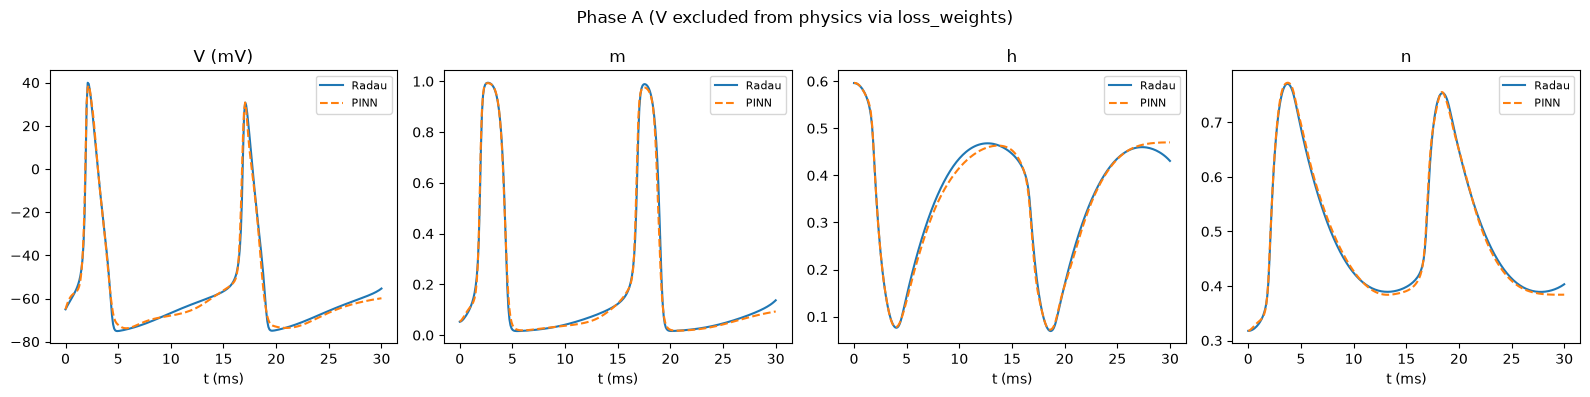

In [16]:
u_a = eval_trajectory(trainer_a, t_eval)
plot_vs_radau(t_eval, u_a, u_ref_eval, "Phase A (V excluded from physics via loss_weights)")
rel_l2_report(u_a, u_ref_eval, "Phase A")

#### Phase B: joint fine-tune (physics reintroduced for V)

In [17]:
problem_b = make_problem(data_mask_v_only)
trainer_b = Trainer(trainer_a.params, activation, problem_b,
                    lr=2e-4, residual_weight=1.0,
                    loss_weights=[0.02, GATE_W, GATE_W, GATE_W],
                    use_grad_clip=True, grad_clip_norm=0.1)
trainer_b.train(steps=14_000, batch_size=64, tol=1e-9, log_every=14_000)

step  14000 | mean loss: 0.0085 | 18.8s


[{'step': 14000,
  'mean_loss': 0.008478799968592025,
  'res_per_var': Array([8.8196797e-03, 1.0187864e-04, 9.4835414e-05, 5.3023938e-05],      dtype=float32)}]

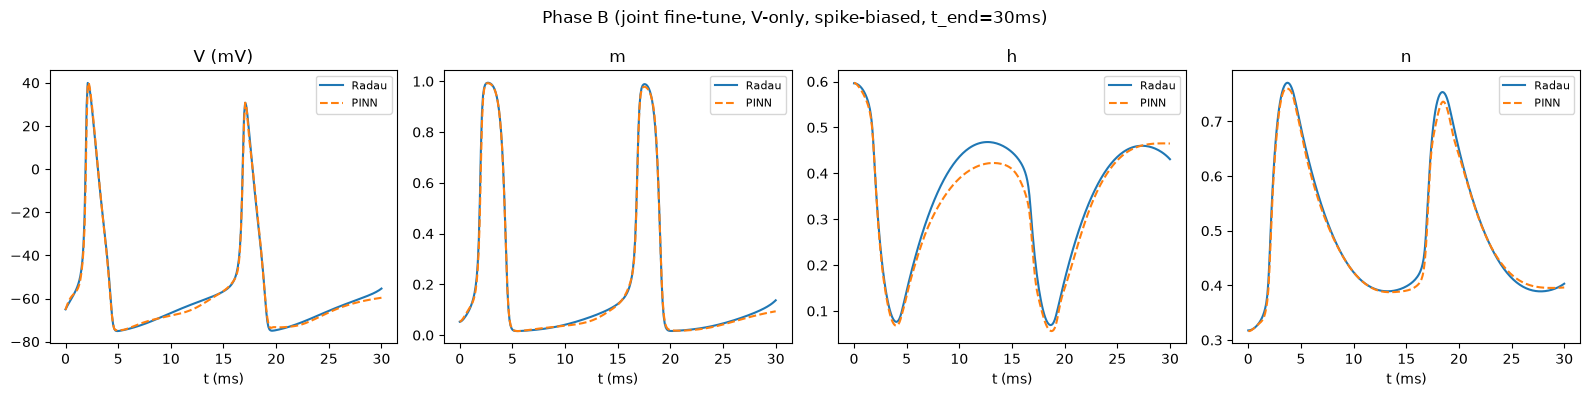

Phase B final: V=0.025  m=0.031  h=0.072  n=0.018  avg=0.036  max=0.072


[np.float64(0.02474831312457009),
 np.float64(0.031247327815619307),
 np.float64(0.07168403202639874),
 np.float64(0.01827886058731735)]

In [18]:
u_b = eval_trajectory(trainer_b, t_eval)
fig = plot_vs_radau(t_eval, u_b, u_ref_eval, "Phase B (joint fine-tune, V-only, spike-biased, t_end=30ms)")
fig.savefig("../assets/stage2_final_result.png", dpi=200, bbox_inches="tight")
plt.show()
rel_l2_report(u_b, u_ref_eval, "Phase B final")